# 3) Adaptive split

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'ts-forecasting'
SEED = 42
VAL_CUTOFF = 2880
SAMPLE_SIZE = 200

train = pd.read_parquet(
    DATA_DIR / 'train.parquet',
    columns=['code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'y_target', 'weight'],
)
series_keys = ['code', 'sub_code', 'sub_category', 'horizon']

print(f'Train rows: {len(train):,}')

Train rows: 5,337,414


In [2]:
def get_series_full(df, row, series_keys):
    mask = np.ones(len(df), dtype=bool)
    for key in series_keys:
        mask &= df[key] == row[key]

    subset = df.loc[mask].sort_values('ts_index')

    return subset['y_target'].reset_index(drop=True)

In [3]:
def split_80_20(series):
    split = int(len(series) * 0.8)
    return series[:split], series[split:]

In [4]:
def safe_arima(train, steps, order):
    try:
        model = ARIMA(train, order=order).fit()
        return model.forecast(steps)
    except:
        return np.repeat(np.mean(train), steps)


def safe_sarima(train, steps, order, seasonal_order):
    try:
        model = SARIMAX(train, order=order, seasonal_order=seasonal_order).fit(disp=False)
        return model.forecast(steps)
    except:
        return np.repeat(np.mean(train), steps)

In [5]:
def get_models(train_len):

    # avoid overfitting on small data
    if train_len < 30:
        return {
            "AR(1)": lambda tr, n: safe_arima(tr, n, (1,0,0)),
            "ARIMA(1,1,1)": lambda tr, n: safe_arima(tr, n, (1,1,1)),
        }

    return {
        # AR
        "AR(1)": lambda tr, n: safe_arima(tr, n, (1,0,0)),
        "AR(2)": lambda tr, n: safe_arima(tr, n, (2,0,0)),

        # MA
        "MA(1)": lambda tr, n: safe_arima(tr, n, (0,0,1)),
        "MA(2)": lambda tr, n: safe_arima(tr, n, (0,0,2)),

        # ARMA
        "ARMA(1,1)": lambda tr, n: safe_arima(tr, n, (1,0,1)),
        "ARMA(2,2)": lambda tr, n: safe_arima(tr, n, (2,0,2)),

        # ARIMA
        "ARIMA(1,1,0)": lambda tr, n: safe_arima(tr, n, (1,1,0)),
        "ARIMA(1,1,1)": lambda tr, n: safe_arima(tr, n, (1,1,1)),

        # SARIMA (use small seasonal assumption)
        "SARIMA": lambda tr, n: safe_sarima(tr, n, (1,1,1), (1,0,0,12)),
    }

In [6]:
def plot_models_80_20(series, title):
    train, val = split_80_20(series)

    models = get_models(len(train))

    plt.figure(figsize=(14,6))

    train_idx = range(len(train))
    val_idx = range(len(train), len(series))

    # actual
    plt.plot(train_idx, train, label='Train', linewidth=2)
    plt.plot(val_idx, val, label='Actual', linewidth=2)

    # predictions
    for name, func in models.items():
        preds = func(train, len(val))
        plt.plot(val_idx, preds, label=name, alpha=0.7)

    plt.axvline(len(train), linestyle='--', color='black', label='Split')

    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

In [7]:
series_stats = (
    train.groupby(series_keys)
         .agg(length=('ts_index', 'size'),
              start=('ts_index', 'min'),
              end=('ts_index', 'max'),
              total_weight=('weight', 'sum'),
              target_std=('y_target', 'std'))
         .reset_index()
)
series_stats['crosses_cutoff'] = (series_stats['start'] <= VAL_CUTOFF) & (series_stats['end'] > VAL_CUTOFF)

print(f'Total series: {len(series_stats)}')
print(f'Series crossing VAL_CUTOFF={VAL_CUTOFF}: {series_stats["crosses_cutoff"].sum()}')
series_stats[['length', 'start', 'end']].describe().T

Total series: 36923
Series crossing VAL_CUTOFF=2880: 1930


,count,mean,std,min,25%,50%,75%,max
length,36923.0,144.555264,56.770160,1.0,104.0,166.0,194.0,213.0
start,36923.0,1894.655716,1045.470184,1.0,1031.0,1968.0,2787.0,3600.0
end,36923.0,2046.371124,1045.023400,1.0,1181.0,2127.0,2948.0,3601.0


In [8]:
eligible = series_stats[(series_stats['crosses_cutoff']) & (series_stats['length'] >= 120)].copy()
eligible['target_std'] = eligible['target_std'].fillna(0.0)
stable_pool = eligible[eligible['target_std'] > 0]

chosen = pd.concat([
    eligible.nlargest(1, 'length').assign(reason='longest history'),
    eligible.nlargest(1, 'total_weight').assign(reason='highest total weight'),
    eligible.nlargest(1, 'target_std').assign(reason='most volatile'),
    stable_pool.nsmallest(1, 'target_std').assign(reason='most stable'),
], ignore_index=True).drop_duplicates(subset=series_keys)

chosen[[*series_keys, 'reason', 'length', 'total_weight', 'target_std']]

,code,sub_code,sub_category,horizon,reason,length,total_weight,target_std
0,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,longest history,212,9.060035e+02,2.641558
1,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,highest total weight,156,4.349747e+10,0.000394
2,W4S29LF4,KL66VIS3,PHHHVYZI,25,most volatile,162,4.562944e-01,296.760011
3,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,most stable,170,3.869062e+10,0.000139



Plotting (80-20): longest history
Series length: 212


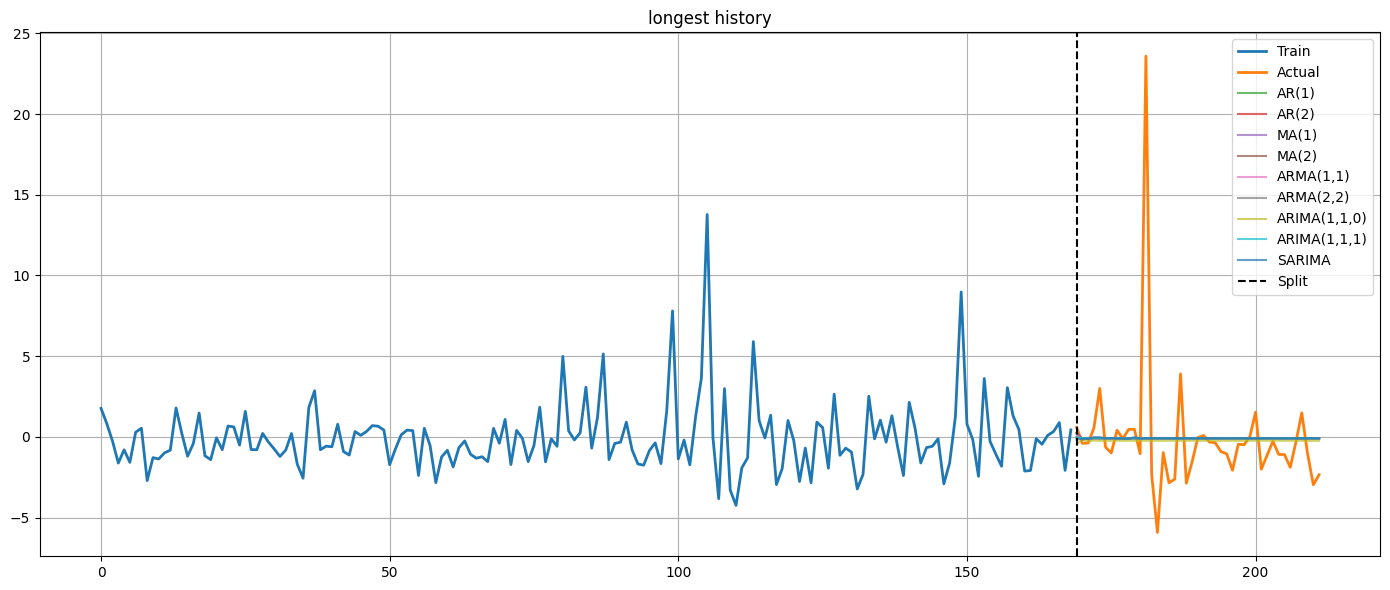


Plotting (80-20): highest total weight
Series length: 156


/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodel

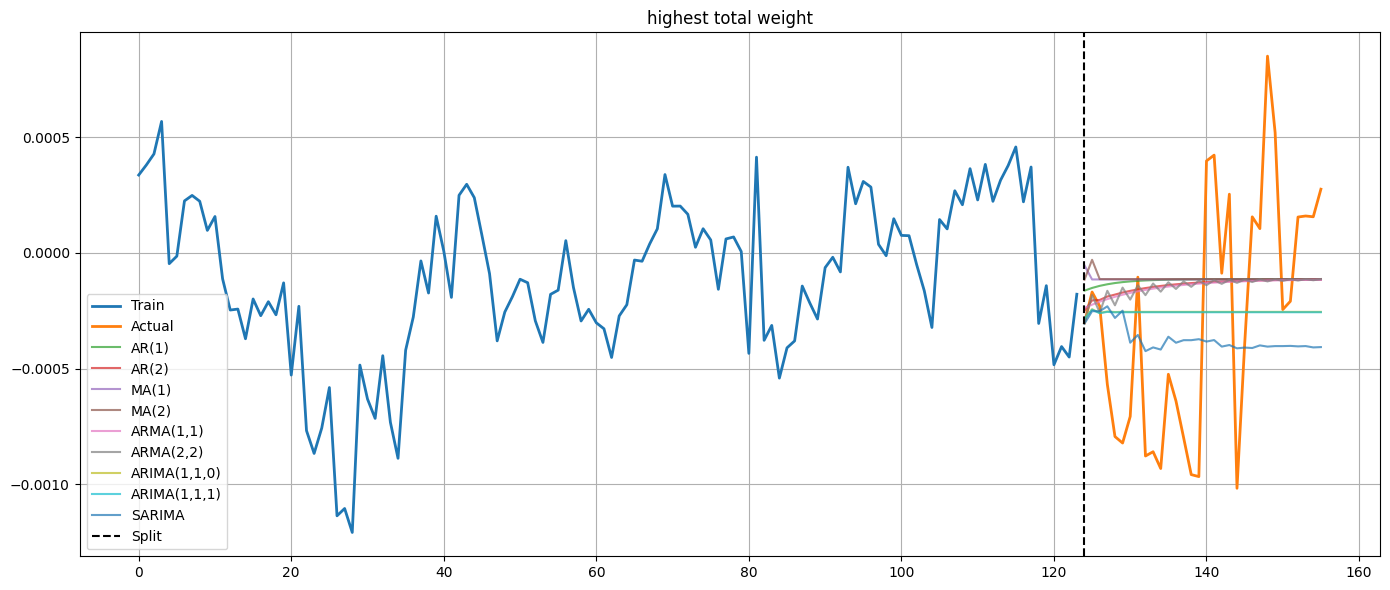


Plotting (80-20): most volatile
Series length: 162


/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


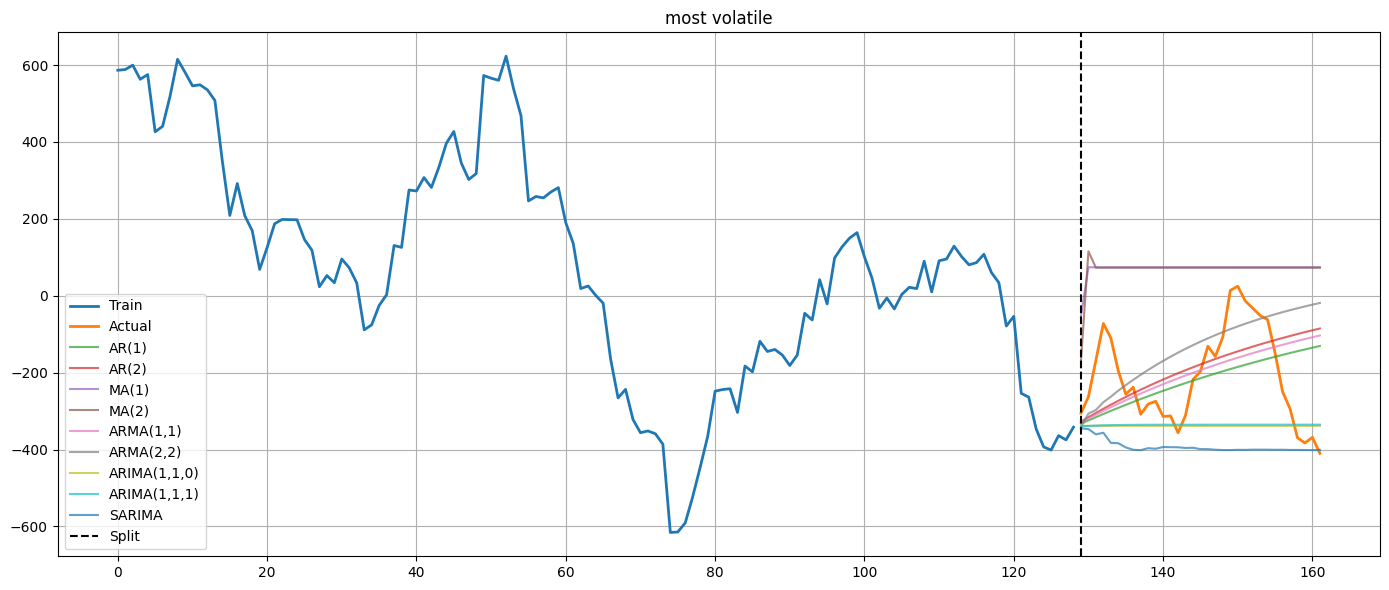


Plotting (80-20): most stable
Series length: 170


/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodel

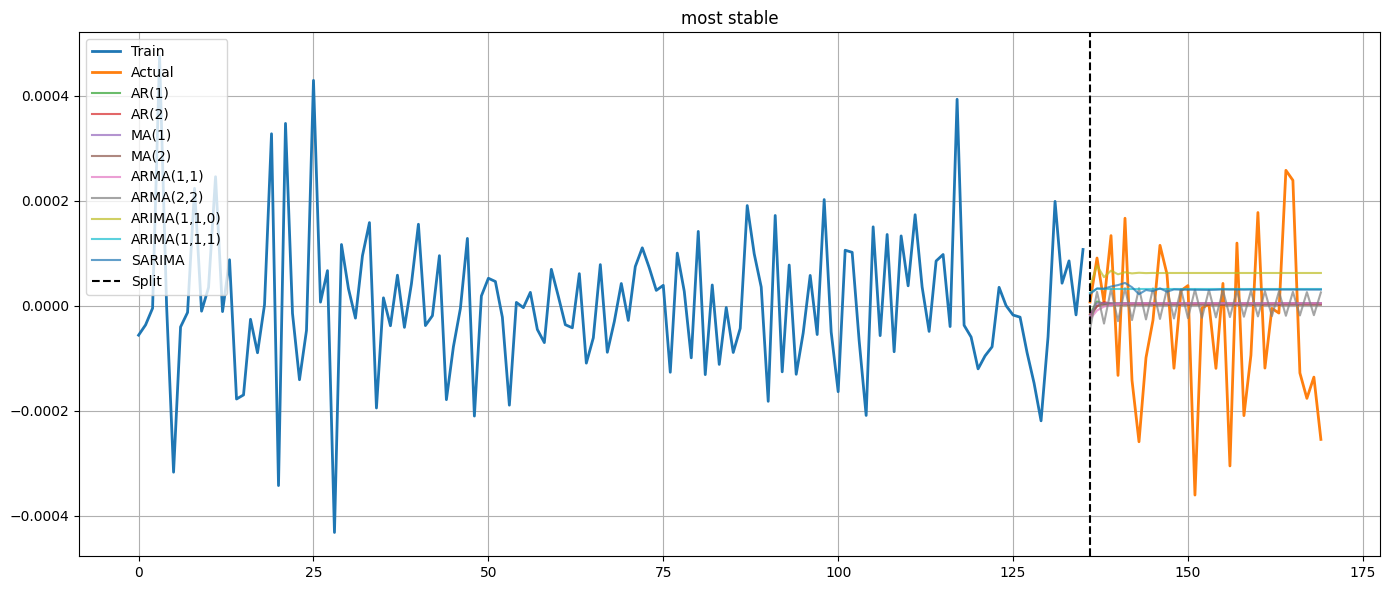

In [9]:
for _, row in chosen.iterrows():
    series = get_series_full(train, row, series_keys)

    print(f"\nPlotting (80-20): {row['reason']}")
    print(f"Series length: {len(series)}")

    plot_models_80_20(series, title=row['reason'])

In [10]:
from statsmodels.tsa.stattools import acf, pacf
import numpy as np

def detect_pq(series, max_lag=20):
    acf_vals = acf(series, nlags=max_lag, fft=True)
    pacf_vals = pacf(series, nlags=max_lag)

    # threshold (confidence band approx)
    threshold = 1.96 / np.sqrt(len(series))

    # detect p from PACF
    p = 0
    for i in range(1, max_lag):
        if abs(pacf_vals[i]) > threshold:
            p = i
            break

    # detect q from ACF
    q = 0
    for i in range(1, max_lag):
        if abs(acf_vals[i]) > threshold:
            q = i
            break

    # cap to avoid overfitting
    p = min(p, 3)
    q = min(q, 3)

    return p, q

In [11]:
def run_models(train, val):

    results = {}
    p, q = detect_pq(train)

    steps = len(val)

    # AR
    try:
        model = ARIMA(train, order=(p,0,0)).fit()
        results[f"AR({p})"] = model.forecast(steps)
    except:
        pass

    # MA
    try:
        model = ARIMA(train, order=(0,0,q)).fit()
        results[f"MA({q})"] = model.forecast(steps)
    except:
        pass

    # ARMA
    try:
        model = ARIMA(train, order=(p,0,q)).fit()
        results[f"ARMA({p},{q})"] = model.forecast(steps)
    except:
        pass

    # ARIMA
    try:
        model = ARIMA(train, order=(p,1,q)).fit()
        results[f"ARIMA({p},1,{q})"] = model.forecast(steps)
    except:
        pass

    # SARIMA (only if enough data)
    try:
        if len(train) > 50:
            model = SARIMAX(train, order=(p,1,q),
                            seasonal_order=(1,0,0,12)).fit(disp=False)
            results[f"SARIMA"] = model.forecast(steps)
    except:
        pass

    return results, p, q

In [12]:
from sklearn.metrics import mean_squared_error

def rmse(y, yhat):
    return np.sqrt(mean_squared_error(y, yhat))

In [13]:
import matplotlib.pyplot as plt

def plot_series_models(train, val, preds_dict, title):

    plt.figure(figsize=(12,5))

    train_idx = range(len(train))
    val_idx = range(len(train), len(train)+len(val))

    plt.plot(train_idx, train, label='Train', linewidth=2)
    plt.plot(val_idx, val, label='Actual', linewidth=2)

    for name, preds in preds_dict.items():
        plt.plot(val_idx, preds, label=name)

    plt.axvline(len(train), linestyle='--', color='black')

    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [15]:
def get_series(df, row, series_keys):

    import numpy as np

    

    mask = np.ones(len(df), dtype=bool)

    for key in series_keys:

        mask &= df[key] == row[key]

    subset = df.loc[mask].sort_values('ts_index')

    return subset['y_target'].reset_index(drop=True)


Series: longest history
Detected p=3, q=0


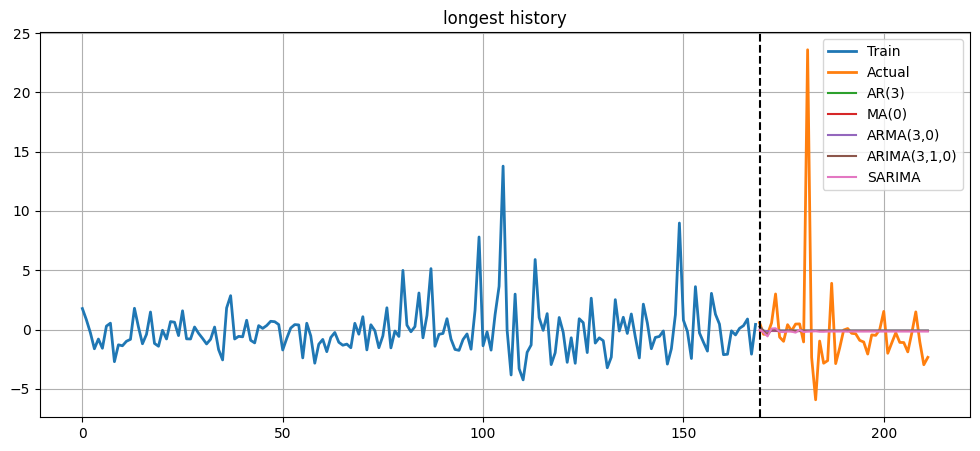


Series: highest total weight
Detected p=1, q=1


/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodel

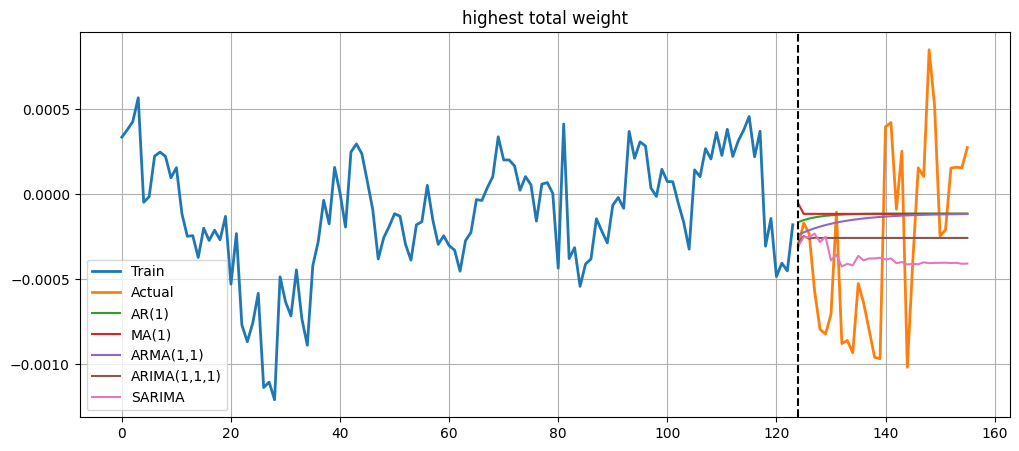


Series: most volatile
Detected p=1, q=1


/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


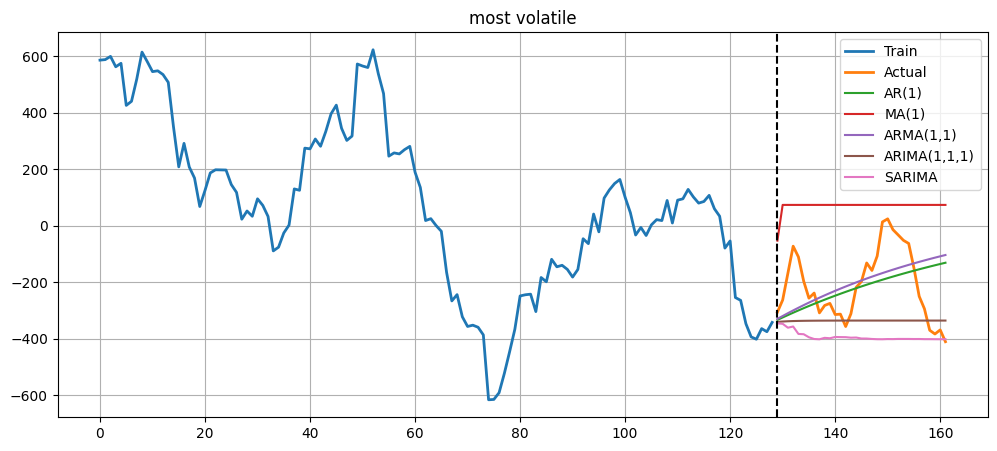

/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/lib/python3.14/site-packages/statsmodel


Series: most stable
Detected p=1, q=1


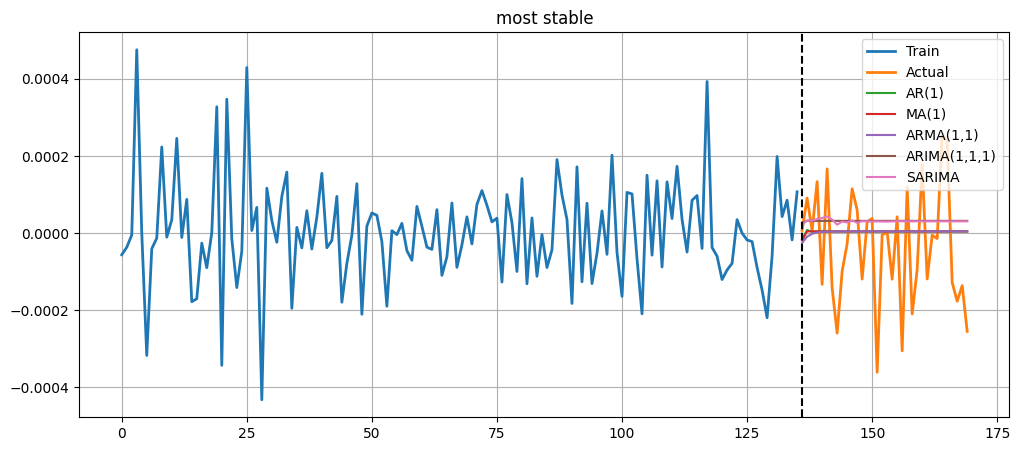

                  Series         Model        RMSE  p  q
8   highest total weight  ARIMA(1,1,1)    0.000511  1  1
7   highest total weight     ARMA(1,1)    0.000516  1  1
5   highest total weight         AR(1)    0.000532  1  1
9   highest total weight        SARIMA    0.000534  1  1
6   highest total weight         MA(1)    0.000536  1  1
4        longest history        SARIMA    3.998232  3  0
3        longest history  ARIMA(3,1,0)    3.998960  3  0
0        longest history         AR(3)    4.002737  3  0
2        longest history     ARMA(3,0)    4.002737  3  0
1        longest history         MA(0)    4.003908  3  0
15           most stable         AR(1)    0.000155  1  1
16           most stable         MA(1)    0.000155  1  1
17           most stable     ARMA(1,1)    0.000156  1  1
19           most stable        SARIMA    0.000164  1  1
18           most stable  ARIMA(1,1,1)    0.000165  1  1
10         most volatile         AR(1)  135.940720  1  1
12         most volatile     AR

In [16]:
summary = []

for _, row in chosen.iterrows():

    series = get_series(train, row, series_keys)

    train_s, val_s = split_80_20(series)

    preds_dict, p, q = run_models(train_s, val_s)

    print(f"\nSeries: {row['reason']}")
    print(f"Detected p={p}, q={q}")

    # compute RMSE
    for name, preds in preds_dict.items():
        score = rmse(val_s, preds)

        summary.append({
            "Series": row['reason'],
            "Model": name,
            "RMSE": score,
            "p": p,
            "q": q
        })

    # plot
    plot_series_models(train_s, val_s, preds_dict, row['reason'])

summary_df = pd.DataFrame(summary)
print(summary_df.sort_values(['Series','RMSE']))